# SBTi Target Analysis

This notebook compares the climate targets of Tesco, Sainsbury's and Walmart using data from the Science Based Targets initiative (SBTi).

The initial analysis focuses on near-term Scope 1 and 2 targets and derives an annualised target reduction rate to improve comparability between targets with different base years and target years.

## Tesco's operational emissions performance

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = {
    "company": ["Tesco", "Sainsbury's", "Walmart"], 
    "annualised_rate":[9.78, 9.06,5.29]
}
df= pd.DataFrame(data)
df

,company,annualised_rate
0,Tesco,9.78
1,Sainsbury's,9.06
2,Walmart,5.29


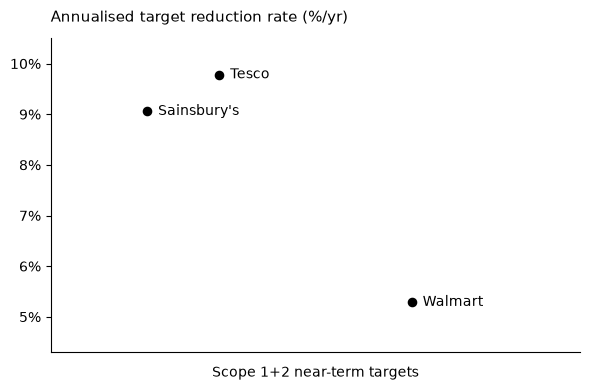

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

# Manual x-positions for visual spacing
x_positions = [0.35, 0.20, 0.75]

# Plot the three points
ax.scatter(
    x_positions,
    df["annualised_rate"],
    s=35,
    color = "black"
)

# Add company names next to each point
for x, rate, company in zip(
    x_positions,
    df["annualised_rate"],
    df["company"]
):
    ax.annotate(
        company,
        xy=(x, rate),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        fontsize=10
    )

# Y-axis
ax.set_ylim(4.3, 10.5)
ax.set_yticks([5, 6, 7, 8, 9, 10])
ax.set_yticklabels(["5%", "6%", "7%", "8%", "9%", "10%"])

# X-axis width
ax.set_xlim(0, 1.1)

# We don't need numerical x-axis ticks
ax.set_xticks([])

# Title
ax.set_title(
    "Annualised target reduction rate (%/yr)",
    loc="left",
    fontsize=11,
    pad=12
)

# X-axis description
ax.set_xlabel(
    "Scope 1+2 near-term targets",
    fontsize=10,
    labelpad=10
)

# Keep the L-shaped axes
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)

# Remove only the unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Tesco operational emissions performance

The table below reproduces Tesco's reported Group Scope 1 and market-based Scope 2 emissions data for the available reporting years.

Scope 1 and Scope 2 are retained separately, alongside the reported combined Scope 1+2 total, to support later comparison against Tesco's SBTi near-term target.

In [3]:
tesco_data = {
    "reporting_year": [
        "2015/16",
        "2021/22",
        "2022/23",
        "2023/24",
        "2024/25",
        "2025/26"
    ],
    "scope1_tco2e": [
        1240871,
        1110098,
        1039346,
        902830,
        802425,
        734003
    ],
    "scope2_market_tco2e": [
        1095671,
        16107,
        7796,
        6259,
        5497,
        5789
    ],
    "scope12_tco2e": [
        2336542,
        1126205,
        1047142,
        909089,
        807921,
        739792
    ]
}

tesco_df = pd.DataFrame(tesco_data)

tesco_df

,reporting_year,scope1_tco2e,scope2_market_tco2e,scope12_tco2e
0,2015/16,1240871,1095671,2336542
1,2021/22,1110098,16107,1126205
2,2022/23,1039346,7796,1047142
3,2023/24,902830,6259,909089
4,2024/25,802425,5497,807921
5,2025/26,734003,5789,739792


In [4]:
baseline = tesco_df.loc[0, "scope12_tco2e"]

tesco_df["reduction_from_baseline_pct"] = (
    (baseline - tesco_df["scope12_tco2e"]) / baseline
) * 100

tesco_df["reduction_from_baseline_pct"] = (
    tesco_df["reduction_from_baseline_pct"].round(2)
)

tesco_df

,reporting_year,scope1_tco2e,scope2_market_tco2e,scope12_tco2e,reduction_from_baseline_pct
0,2015/16,1240871,1095671,2336542,0.00
1,2021/22,1110098,16107,1126205,51.80
2,2022/23,1039346,7796,1047142,55.18
3,2023/24,902830,6259,909089,61.09
4,2024/25,802425,5497,807921,65.42
5,2025/26,734003,5789,739792,68.34


In [6]:
sbti_target_reduction_pct = 82.6
sbti_target_year = 2032
target_emissions = baseline * (1 - sbti_target_reduction_pct / 100)

target_emissions

np.float64(406558.3080000001)

In [7]:
current_emissions = tesco_df.loc[
    tesco_df["reporting_year"] == "2025/26",
    "scope12_tco2e"
].iloc[0]

remaining_reduction_tco2e = current_emissions - target_emissions

remaining_reduction_tco2e

np.float64(333233.6919999999)

In [8]:
remaining_reduction_pct_current = (
    remaining_reduction_tco2e / current_emissions
) * 100

remaining_reduction_pct_current

np.float64(45.04424108398035)

In [9]:
tesco_progress = pd.DataFrame({
    "metric": [
        "Baseline emissions",
        "Current emissions",
        "Reduction achieved",
        "SBTi target reduction",
        "Implied target emissions",
        "Remaining emissions reduction",
        "Remaining reduction from current emissions"
    ],
    "value": [
        baseline,
        current_emissions,
        tesco_df.loc[
            tesco_df["reporting_year"] == "2025/26",
            "reduction_from_baseline_pct"
        ].iloc[0],
        sbti_target_reduction_pct,
        target_emissions,
        remaining_reduction_tco2e,
        remaining_reduction_pct_current
    ],
    "unit": [
        "tCO2e",
        "tCO2e",
        "%",
        "%",
        "tCO2e",
        "tCO2e",
        "%"
    ]
})

tesco_progress

,metric,value,unit
0,Baseline emissions,2.336542e+06,tCO2e
1,Current emissions,7.397920e+05,tCO2e
2,Reduction achieved,6.834000e+01,%
3,SBTi target reduction,8.260000e+01,%
4,Implied target emissions,4.065583e+05,tCO2e
5,Remaining emissions reduction,3.332337e+05,tCO2e
6,Remaining reduction from current emissions,4.504424e+01,%


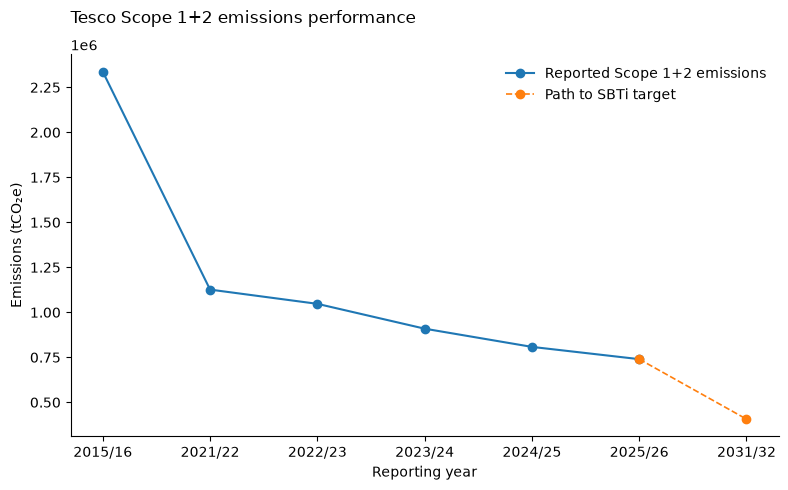

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

# Actual reported emissions
ax.plot(
    tesco_df["reporting_year"],
    tesco_df["scope12_tco2e"],
    marker="o",
    linewidth=1.5,
    label="Reported Scope 1+2 emissions"
)

# Required path from current emissions to FY2032 target
ax.plot(
    ["2025/26", "2031/32"],
    [current_emissions, target_emissions],
    marker="o",
    linestyle="--",
    linewidth=1.2,
    label="Path to SBTi target"
)

ax.set_title(
    "Tesco Scope 1+2 emissions performance",
    loc="left",
    fontsize=12,
    pad=12
)

ax.set_ylabel("Emissions (tCO₂e)")
ax.set_xlabel("Reporting year")

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
years_remaining = 6

required_annual_rate = (
    1 - (target_emissions / current_emissions) ** (1 / years_remaining)
) * 100

required_annual_rate

np.float64(9.495771984041335)

In [13]:
pathway_years = [
    "2025/26",
    "2026/27",
    "2027/28",
    "2028/29",
    "2029/30",
    "2030/31",
    "2031/32"
]

pathway_emissions = [
    current_emissions * (1 - required_annual_rate / 100) ** year
    for year in range(7)
]

pathway_df = pd.DataFrame({
    "reporting_year": pathway_years,
    "required_emissions_tco2e": pathway_emissions
})

pathway_df

,reporting_year,required_emissions_tco2e
0,2025/26,739792.000000
1,2026/27,669543.038524
2,2027/28,605964.758251
3,2028/29,548423.726503
4,2029/30,496346.659928
5,2030/31,449214.712851
6,2031/32,406558.308000


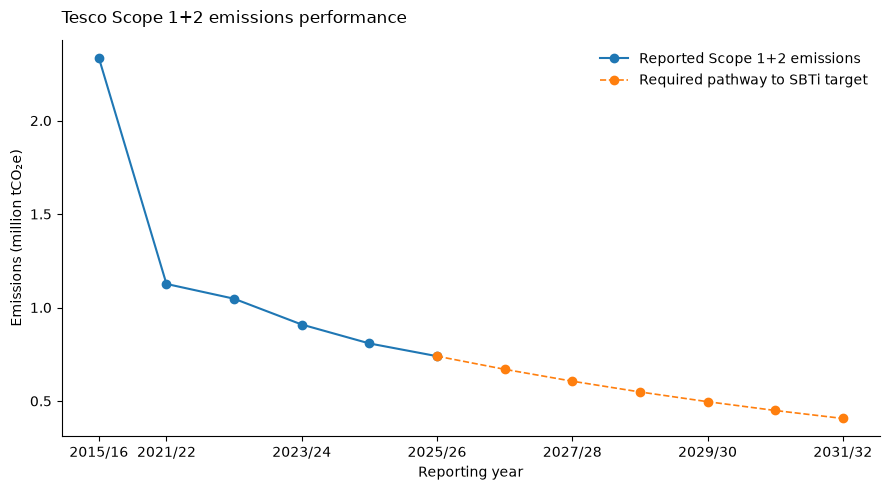

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

# Reported emissions
ax.plot(
    tesco_df["reporting_year"],
    tesco_df["scope12_tco2e"],
    marker="o",
    linewidth=1.5,
    label="Reported Scope 1+2 emissions"
)

# Required compound pathway
ax.plot(
    pathway_df["reporting_year"],
    pathway_df["required_emissions_tco2e"],
    marker="o",
    linestyle="--",
    linewidth=1.2,
    label="Required pathway to SBTi target"
)

ax.set_title(
    "Tesco Scope 1+2 emissions performance",
    loc="left",
    fontsize=12,
    pad=12
)

ax.set_ylabel("Emissions (million tCO₂e)")
ax.set_xlabel("Reporting year")

# Cleaner y-axis
ax.set_yticks([
    500000,
    1000000,
    1500000,
    2000000
])

ax.set_yticklabels([
    "0.5",
    "1.0",
    "1.5",
    "2.0"
])

# Show fewer reporting-year labels
ax.set_xticks([
    "2015/16",
    "2021/22",
    "2023/24",
    "2025/26",
    "2027/28",
    "2029/30",
    "2031/32"
])

# Keep floating legend
ax.legend(
    frameon=False,
    loc="upper right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

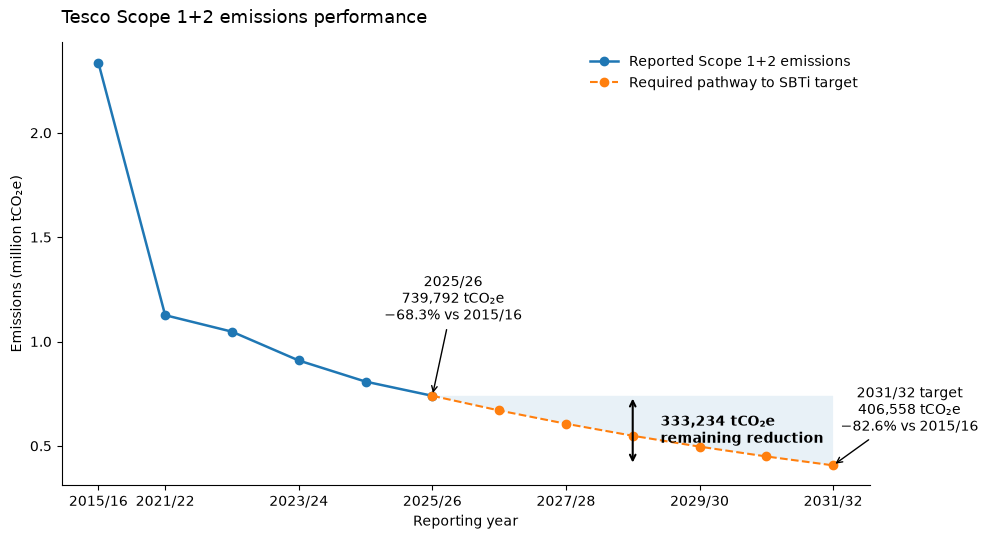

In [20]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# Reported emissions
ax.plot(
    tesco_df["reporting_year"],
    tesco_df["scope12_tco2e"],
    marker="o",
    linewidth=1.8,
    label="Reported Scope 1+2 emissions"
)

# Required compound pathway to SBTi target
ax.plot(
    pathway_df["reporting_year"],
    pathway_df["required_emissions_tco2e"],
    marker="o",
    linestyle="--",
    linewidth=1.5,
    label="Required pathway to SBTi target"
)

# Shade the future reduction gap
ax.fill_between(
    pathway_df["reporting_year"],
    pathway_df["required_emissions_tco2e"],
    current_emissions,
    alpha=0.10
)

# Annotate current emissions
ax.annotate(
    "2025/26\n739,792 tCO₂e\n−68.3% vs 2015/16",
    xy=("2025/26", current_emissions),
    xytext=(15, 55),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    arrowprops=dict(
        arrowstyle="->",
        lw=1
    )
)

# Annotate FY2032 target
ax.annotate(
    "2031/32 target\n406,558 tCO₂e\n−82.6% vs 2015/16",
    xy=("2031/32", target_emissions),
    xytext=(55, 25),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    arrowprops=dict(
        arrowstyle="->",
        lw=1
    )
)

# Position for the remaining emissions gap
gap_x = "2028/29"

# Double-headed arrow showing remaining gap
ax.annotate(
    "",
    xy=(gap_x, current_emissions),
    xytext=(gap_x, target_emissions),
    arrowprops=dict(
        arrowstyle="<->",
        lw=1.5
    )
)

# Label the remaining gap
ax.annotate(
    "333,234 tCO₂e\nremaining reduction",
    xy=(
        gap_x,
        (current_emissions + target_emissions) / 2
    ),
    xytext=(20, 0),
    textcoords="offset points",
    va="center",
    fontsize=10,
    fontweight="bold"
)

# Title
ax.set_title(
    "Tesco Scope 1+2 emissions performance",
    loc="left",
    fontsize=13,
    pad=14
)

# Axis labels
ax.set_ylabel("Emissions (million tCO₂e)")
ax.set_xlabel("Reporting year")

# Cleaner y-axis
ax.set_yticks([
    500000,
    1000000,
    1500000,
    2000000
])

ax.set_yticklabels([
    "0.5",
    "1.0",
    "1.5",
    "2.0"
])

# Reduce x-axis clutter
ax.set_xticks([
    "2015/16",
    "2021/22",
    "2023/24",
    "2025/26",
    "2027/28",
    "2029/30",
    "2031/32"
])

# Floating legend
ax.legend(
    frameon=False,
    loc="upper right"
)

# Minimal chart styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Sainsbury's operational emissions performance

The table below reproduces Sainsbury's reported Scope 1+2 market-based emissions from its 2018/19 baseline through 2025/26.

The emissions series will be used to assess actual operational emissions performance against Sainsbury's SBTi near term Scope 1+2 target.

In [9]:
sainsburys_data = {
    "reporting_year": [
        "2018/19",
        "2019/20",
        "2020/21",
        "2021/22",
        "2022/23",
        "2023/24",
        "2024/25",
        "2025/26"
    ],
    "scope12_tco2e": [
        949744,
        840680,
        817420,
        746681,
        461692,
        458973,
        448734,
        441017
    ]
}

sainsburys_df = pd.DataFrame(sainsburys_data)

sainsburys_df

,reporting_year,scope12_tco2e
0,2018/19,949744
1,2019/20,840680
2,2020/21,817420
3,2021/22,746681
4,2022/23,461692
5,2023/24,458973
6,2024/25,448734
7,2025/26,441017


In [14]:
sainsburys_baseline = sainsburys_df.loc[0, "scope12_tco2e"]

sainsburys_df["reduction_from_baseline_pct"] = (
    (sainsburys_baseline - sainsburys_df["scope12_tco2e"])
     /sainsburys_baseline
    )*100
sainsburys_df["reduction_from_baseline_pct"] = (
    sainsburys_df["reduction_from_baseline_pct"].round(2)
)
sainsburys_df["reduction_from_baseline_pct"] = (
    sainsburys_df["reduction_from_baseline_pct"].round(2)
)

sainsburys_df = sainsburys_df.drop(
    columns=["reductions_from_baseline_pct"])
sainsburys_df

,reporting_year,scope12_tco2e,reduction_from_baseline_pct
0,2018/19,949744,0.00
1,2019/20,840680,11.48
2,2020/21,817420,13.93
3,2021/22,746681,21.38
4,2022/23,461692,51.39
5,2023/24,458973,51.67
6,2024/25,448734,52.75
7,2025/26,441017,53.56


Sainsbury’s has committed to reducing Scope 1+2 by 68%, so by the target year it can have 32% of its baseline emissions remaining.

In [15]:
sainsburys_sbti_target_reduction_pct = 68
sainsburys_sbti_target_year = 2030

sainsburys_target_emissions= (sainsburys_baseline*(1-0.68))
sainsburys_target_emissions

np.float64(303918.07999999996)

In [17]:
sainsburys_current_emissions = sainsburys_df.loc[
    sainsburys_df["reporting_year"] == "2025/26",
    "scope12_tco2e"
].iloc[0]

sainsburys_remaining_reduction_tco2e = (
    sainsburys_current_emissions - sainsburys_target_emissions
)

sainsburys_remaining_reduction_tco2e

np.float64(137098.92000000004)

Given where Sainsbury’s is today, what annual rate of reduction would take it from 441,017 tCO₂e to ~303,918 tCO₂e? For Sainsbury’s, they have 5 years remaining from 2025/26 to 2030/31.

In [19]:
sainsburys_years_remaining = 5
sainsburys_required_annual_rate = (1-(sainsburys_target_emissions/sainsburys_current_emissions)**(1/sainsburys_years_remaining))*100
sainsburys_required_annual_rate                               

np.float64(7.176008119036592)

Start at the actual 441,017 tCO₂e in 2025/26, then reduces the remaining emissions by 7.18% each year, ending at the calculated target of roughly 303,918 tCO₂e in 2030/31.

In [20]:
sainsburys_pathway_years = [
    "2025/26",
    "2026/27",
    "2027/28",
    "2028/29",
    "2029/30",
    "2030/31"
]

sainsburys_pathway_emissions = [
    sainsburys_current_emissions
    * (1 - sainsburys_required_annual_rate / 100) ** year
    for year in range(6)
]

sainsburys_pathway_df = pd.DataFrame({
    "reporting_year": sainsburys_pathway_years,
    "required_emissions_tco2e": sainsburys_pathway_emissions
})

sainsburys_pathway_df

,reporting_year,required_emissions_tco2e
0,2025/26,441017.000000
1,2026/27,409369.584274
2,2027/28,379993.189669
3,2028/29,352724.847527
4,2029/30,327413.283830
5,2030/31,303918.080000


2018/19 baseline → historical performance → 2025/26 actual → required compound pathway → SBTi endpoint.
53.6% achieved
68% SBTi target
137,099 tCO₂e remaining
7.18% annual compound reduction required

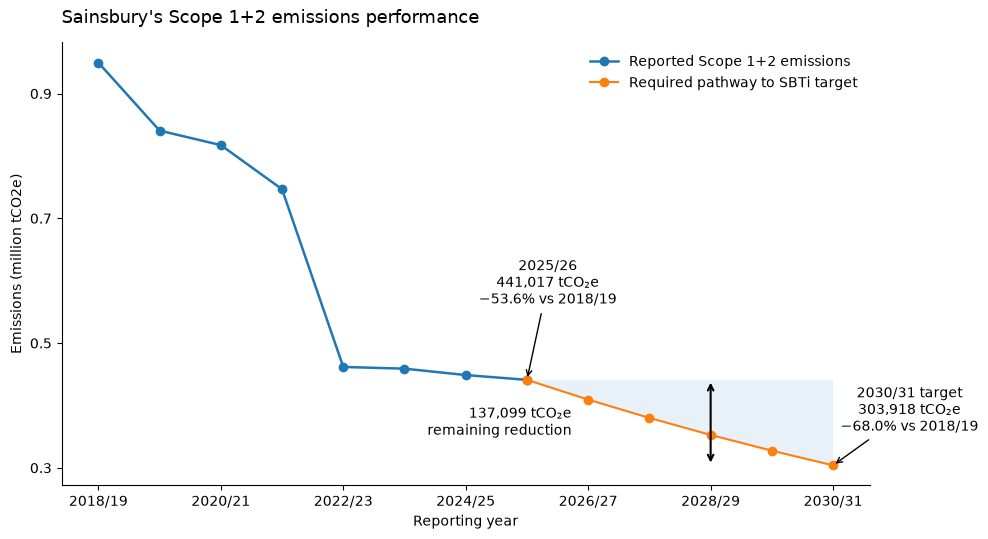

In [30]:
fig, ax = plt.subplots(figsize=(10,5.5))

#Reported emissions
ax.plot(
    sainsburys_df["reporting_year"],
    sainsburys_df["scope12_tco2e"],
    marker= "o",
    linewidth=1.8,
    label = "Reported Scope 1+2 emissions")

#Required compound pathway to SBTI target
ax.plot(
    sainsburys_pathway_df["reporting_year"],
    sainsburys_pathway_df["required_emissions_tco2e"],
    marker="o",
    linewidth=1.5,
    label="Required pathway to SBTi target")
# Shade the future reduction gap
ax.fill_between(
    sainsburys_pathway_df["reporting_year"],
    sainsburys_pathway_df["required_emissions_tco2e"],
    sainsburys_current_emissions,
    alpha=0.10
)

# Annotate current emissions
ax.annotate(
    "2025/26\n441,017 tCO₂e\n−53.6% vs 2018/19",
    xy=("2025/26", sainsburys_current_emissions),
    xytext=(15, 55),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    arrowprops=dict(
        arrowstyle="->",
        lw=1
    )
)

# Annotate SBTi target
ax.annotate(
    "2030/31 target\n303,918 tCO₂e\n−68.0% vs 2018/19",
    xy=("2030/31", sainsburys_target_emissions),
    xytext=(55, 25),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    arrowprops=dict(
        arrowstyle="->",
        lw=1
    )
)

# Position for the remaining emissions gap
gap_x = "2028/29"

# Double-headed arrow showing remaining gap
ax.annotate(
    "",
    xy=(gap_x, sainsburys_current_emissions),
    xytext=(gap_x, sainsburys_target_emissions),
    arrowprops=dict(
        arrowstyle="<->",
        lw=1.5
    )
)

# Label the remaining gap
ax.annotate(
    "137,099 tCO₂e\nremaining reduction",
    xy=(
        gap_x,
        (sainsburys_current_emissions + sainsburys_target_emissions) / 2
    ),
    xytext=(-100, 0),
    textcoords="offset points",
    ha ="right",
    va="center",
    fontsize=10,
 
)

#Ttle
ax.set_title(
    "Sainsbury's Scope 1+2 emissions performance",
    loc="left",
    fontsize=13,
    pad=14)

#Axis labels
ax.set_ylabel("Emissions (million tCO2e)")
ax.set_xlabel("Reporting year")

#cleaner y-axis
ax.set_yticks([
    300000,
    500000,
    700000,
    900000
])

ax.set_yticklabels([
    "0.3",
    "0.5",
    "0.7",
    "0.9"])

#Reduce x-axis clutter
ax.set_xticks([
    "2018/19",
    "2020/21",
    "2022/23",
    "2024/25",
    "2026/27",
    "2028/29",
    "2030/31"])
#Floating legend
ax.legend(
    frameon=False,
    loc="upper right")
# Minimal chart styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretation

Sainsbury's reduced Scope 1+2 market based emissions from 949,744 tCO₂e in 2018/19 to 441,017 tCO₂e in 2025/26, equivalent to a 53.6% reduction from baseline.

Against its SBTi near term target of a 68% reduction by 2030, this implies a target emissions level of approximately 303,918 tCO₂e. A further reduction of around 137,099 tCO₂e is therefore required from the 2025/26 level.

Using a constant compound reduction pathway, Sainsbury's would need to reduce remaining Scope 1+2 emissions by approximately 7.18% per year from 2025/26 to 2030/31 to reach the target endpoint.
